Using device: cuda


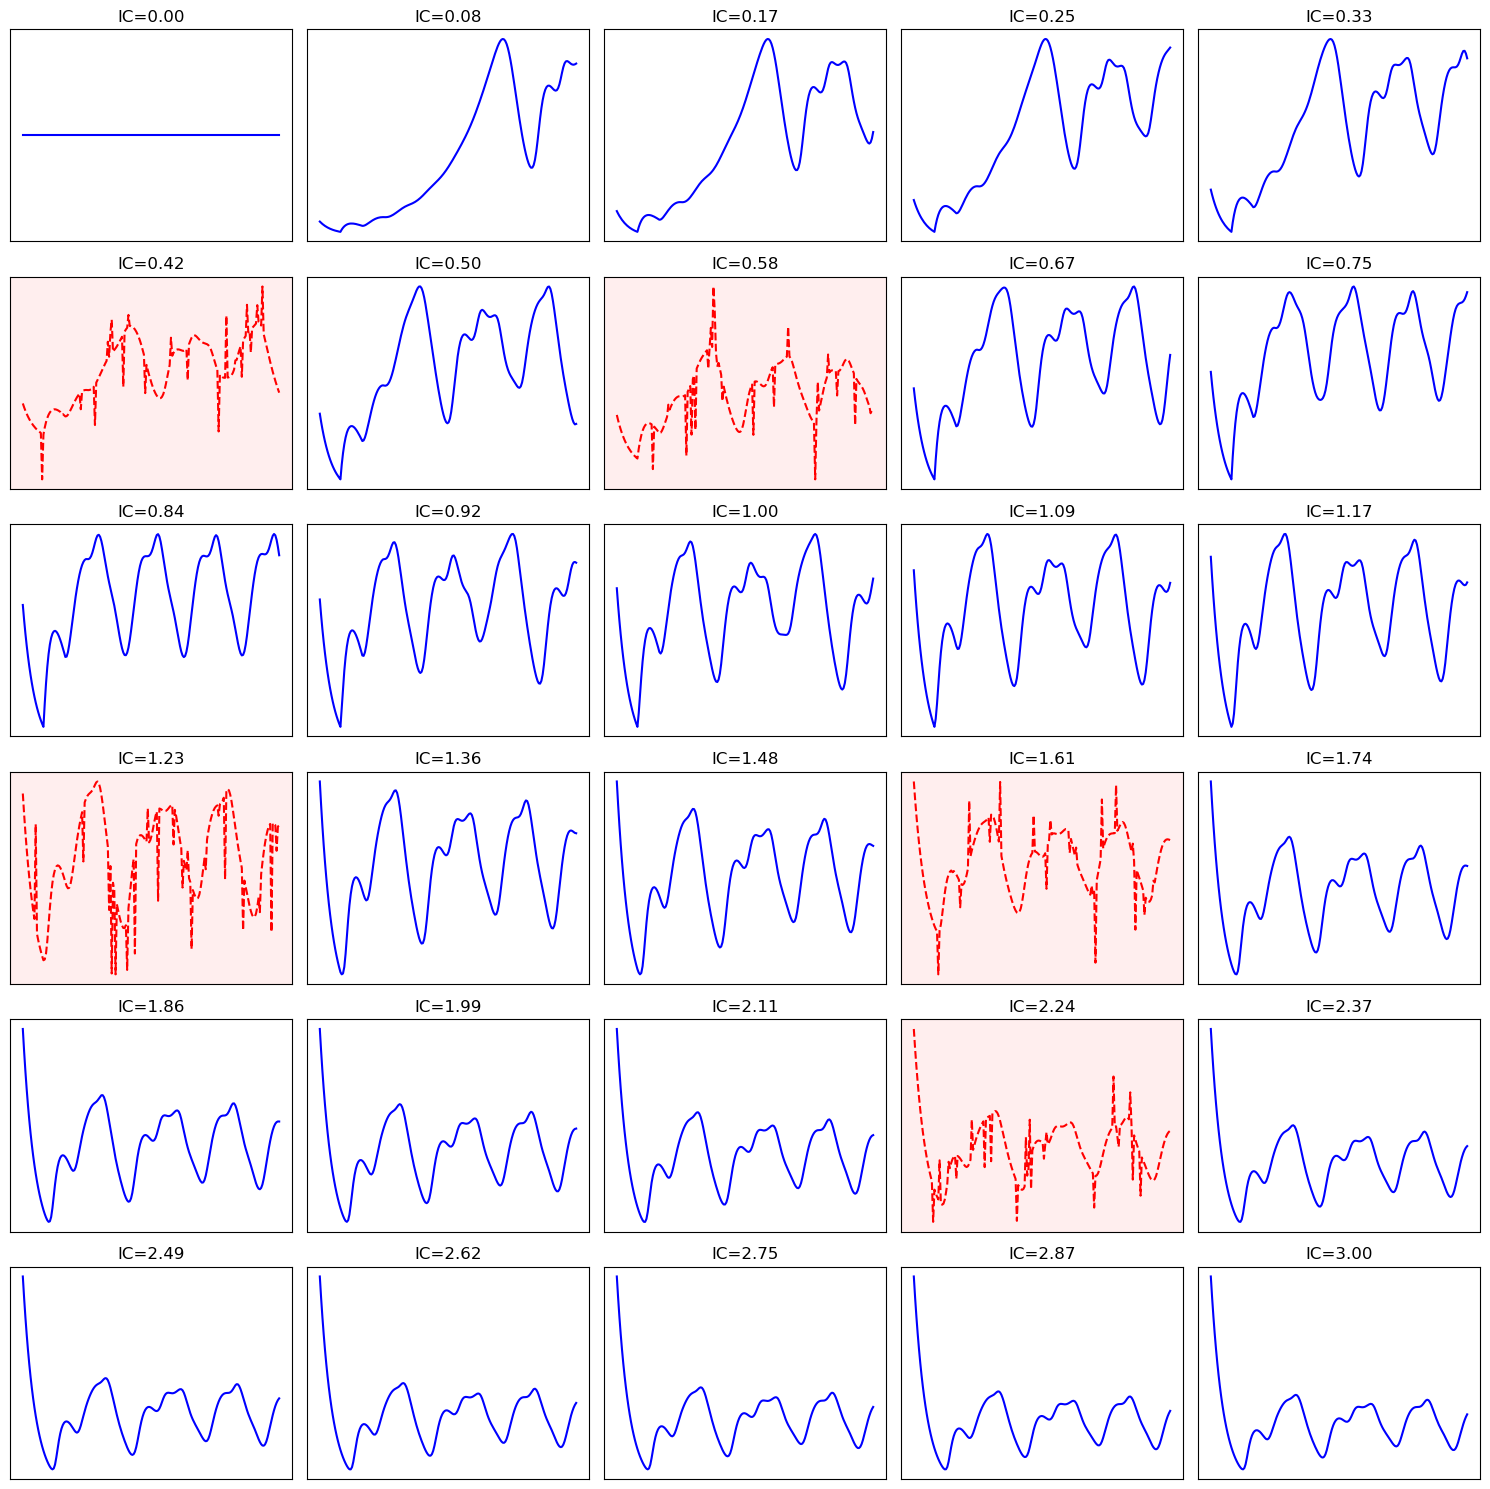

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import time
import random

# --- 1. Fix Python, NumPy, and random seeds ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# --- 2. Force deterministic behavior for cuDNN ---
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Use GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)
    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 0.8
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data ---
X_list, y_list = [], []
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Plot trajectories (optional) ---
import math
n_traj = len(y_list)
n_cols = 5
n_rows = math.ceil(n_traj / n_cols)
plt.figure(figsize=(n_cols*3, n_rows*2.5))
for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--')
        plt.gca().set_facecolor("#ffeeee")
    else:
        plt.plot(x, 'b-')
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([]); plt.yticks([])
plt.tight_layout(); plt.show()

# --- Generate test data ---
x_test = mackey_glass(t_max=200, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0).to(device)

# --- Split into train and val ---
val_split = 1
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

Using device: cuda
Epoch 000 | Val Loss 0.31916
Epoch 001 | Val Loss 0.10654
Epoch 002 | Val Loss 0.09802
Epoch 003 | Val Loss 0.09409
Epoch 004 | Val Loss 0.06494
Epoch 005 | Val Loss 0.05420
Epoch 006 | Val Loss 0.05919
Epoch 007 | Val Loss 0.05434
Epoch 008 | Val Loss 0.03443
Epoch 009 | Val Loss 0.03718
Epoch 010 | Val Loss 0.03046
Epoch 011 | Val Loss 0.02847
Epoch 012 | Val Loss 0.02393
Epoch 013 | Val Loss 0.01832
Epoch 014 | Val Loss 0.01903
Epoch 015 | Val Loss 0.01659
Epoch 016 | Val Loss 0.01771
Epoch 017 | Val Loss 0.01258
Epoch 018 | Val Loss 0.02137
Epoch 019 | Val Loss 0.00885
Epoch 020 | Val Loss 0.02679
Epoch 021 | Val Loss 0.01372
Epoch 022 | Val Loss 0.02126
Epoch 023 | Val Loss 0.01192
Epoch 024 | Val Loss 0.01136
Epoch 025 | Val Loss 0.02589
Epoch 026 | Val Loss 0.01839
Epoch 027 | Val Loss 0.01958
Epoch 028 | Val Loss 0.01035
Epoch 029 | Val Loss 0.01130
Epoch 030 | Val Loss 0.01090
Epoch 031 | Val Loss 0.00939
Epoch 032 | Val Loss 0.00867
Epoch 033 | Val Loss 0.0

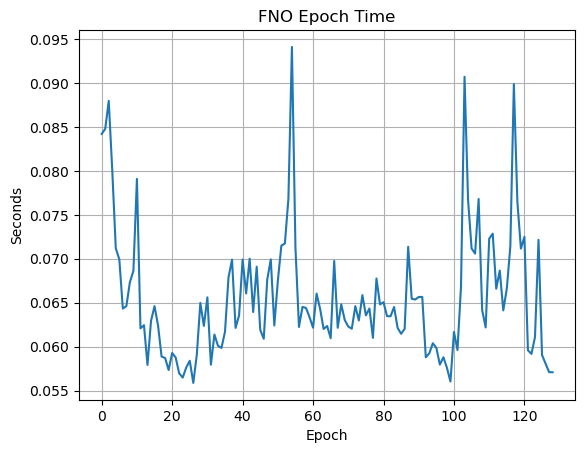

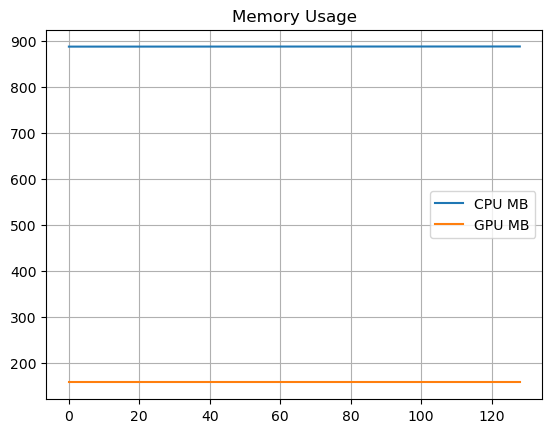

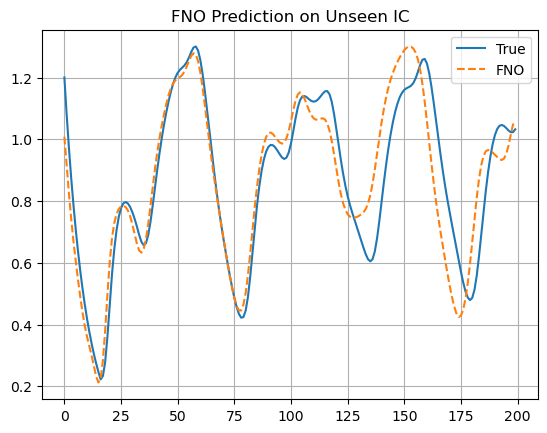

In [6]:
# ============================================================
# Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time
import psutil
import os
import random

# ============================================================
# Reproducibility
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# Mackey–Glass Generator
# ============================================================
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# ============================================================
# Dataset
# ============================================================
t_max = 200
delta_t = 1
timesteps = np.arange(0, t_max, delta_t)

train_ics = np.concatenate([
    np.linspace(0, 1.17, 15),
    np.linspace(1.23, 3, 15)
])
test_ic = 1.2

X_list, y_list = [], []
for ic in train_ics:
    traj = mackey_glass(t_max=t_max, x0=ic)
    norm_t = timesteps / t_max
    X_list.append(np.stack([np.full_like(norm_t, ic), norm_t], axis=1))
    y_list.append(traj)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# Test
x_test = mackey_glass(t_max=t_max, x0=test_ic)
X_test = np.stack([np.full_like(timesteps, test_ic), timesteps / t_max], axis=1)

# ============================================================
# Normalize
# ============================================================
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

X_tensor = torch.tensor(X, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(0).to(device)
y_test = x_test

# ============================================================
# DataLoaders
# ============================================================
dataset = TensorDataset(X_tensor, y_tensor)
train_ds, val_ds = random_split(dataset, [len(dataset)-1, 1])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)

# ============================================================
# FNO Components
# ============================================================
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.modes = modes
        self.scale = 1 / (in_channels * out_channels)
        self.weights_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes))
        self.weights_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes))

    def forward(self, x):
        x_ft = torch.fft.rfft(x, dim=-1)
        modes = min(self.modes, x_ft.size(-1))
        out_ft = torch.einsum(
            "bcm,com->bom",
            x_ft[:, :, :modes],
            torch.complex(self.weights_real[:, :, :modes], self.weights_imag[:, :, :modes])
        )
        out_ft_full = torch.zeros(x.size(0), out_ft.size(1), x_ft.size(-1),
                                  dtype=torch.cfloat, device=x.device)
        out_ft_full[:, :, :modes] = out_ft
        return torch.fft.irfft(out_ft_full, n=x.size(-1), dim=-1)

class FNO1d(nn.Module):
    def __init__(self, modes=16, width=64):
        super().__init__()
        self.fc0 = nn.Linear(2, width)

        self.convs = nn.ModuleList([SpectralConv1d(width, width, modes) for _ in range(4)])
        self.ws = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(4)])

        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc0(x).permute(0, 2, 1)
        for conv, w in zip(self.convs, self.ws):
            x = F.gelu(conv(x) + w(x))
        x = x.permute(0, 2, 1)
        return self.fc2(F.gelu(self.fc1(x))).squeeze(-1)

# ============================================================
# Instantiate
# ============================================================
model = FNO1d().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ============================================================
# Resource Tracking
# ============================================================
def cpu_mem():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2

def gpu_mem():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024**2
    return None

epoch_times, cpu_mem_log, gpu_mem_log = [], [], []

# ============================================================
# Training
# ============================================================
epochs = 200
best_val = float("inf")
patience, wait = 30, 0

start_train = time.time()
for ep in range(epochs):
    ep_start = time.time()
    model.train()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(xv.to(device)), yv.to(device)).item()
                       for xv, yv in val_loader)

    epoch_times.append(time.time() - ep_start)
    cpu_mem_log.append(cpu_mem())
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        gpu_mem_log.append(gpu_mem())

    print(f"Epoch {ep:03d} | Val Loss {val_loss:.5f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

total_train_time = time.time() - start_train
print(f"\nTotal training time: {total_train_time:.2f}s")

# ============================================================
# Inference Timing
# ============================================================
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    t0 = time.time()
    for _ in range(50):
        _ = model(X_test_tensor)
    infer_time = (time.time() - t0) / 50

print(f"Inference time per trajectory: {infer_time:.6f}s")

# ============================================================
# Evaluation
# ============================================================
with torch.no_grad():
    pred = model(X_test_tensor).cpu().numpy().flatten()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))

# ============================================================
# Plots
# ============================================================
plt.figure()
plt.plot(epoch_times)
plt.title("FNO Epoch Time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.grid()
plt.show()

plt.figure()
plt.plot(cpu_mem_log, label="CPU MB")
if gpu_mem_log:
    plt.plot(gpu_mem_log, label="GPU MB")
plt.legend()
plt.title("Memory Usage")
plt.grid()
plt.show()

plt.figure()
plt.plot(y_test, label="True")
plt.plot(pred, '--', label="FNO")
plt.legend()
plt.title("FNO Prediction on Unseen IC")
plt.grid()
plt.show()


In [4]:
# Save as NumPy arrays
np.save("train_losses.npy", train_losses)
np.save("val_losses.npy", val_losses)

# Divergence
errors = np.abs(pred_test_fno - y_test)            # abs error
rmse_window = np.sqrt((pred_test_fno - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Compute divergence
threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold)
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Error Threshold ({threshold})')

# Get plot limits
x_min, x_max = 0, len(smoothed_error)
y_min, y_max = 0, max(smoothed_error)*1.1  # leave a little top margin

# Dynamically set annotation position inside bounds
x_text = divergence_time+ 5
if x_text > x_max-20:
    x_text = divergence_time - 20
x_text = np.clip(x_text, x_min, x_max)  # ensure inside x limits

y_text = smoothed_error[divergence_time] +0.01
y_text = np.clip(y_text, y_min, y_max)  # ensure inside y limits

# Annotate divergence time
plt.annotate(
    f'Divergence: {divergence_time} steps',
    xy=(divergence_time, smoothed_error[divergence_time]),
    xytext=(x_text, y_text),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10,
    color='black'
)

plt.title("Prediction Divergence Over Time (Fourier Neural Operator)")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'train_losses' is not defined